# Train the transfer model

This notebook trains a frozen ImageNet-pretrained ResNet18 classification head. It uses training and validation data only; the test split stays untouched.

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/movie_classifier.zip

## Colab setup

1. Select **Runtime > Change runtime type > GPU**.
2. Put this project and its ignored `frames/` directory in Google Drive.
3. Update `PROJECT_DIR` below if your Drive folder has a different name.
4. Run the notebook from top to bottom.

The repository dependencies must already be available in the Colab environment.

In [2]:
import os
import sys
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/movie_classifier")
os.chdir(PROJECT_DIR)
sys.path.insert(0, str(PROJECT_DIR))

assert Path("train_transfer.py").exists(), "Set PROJECT_DIR to the repository directory."
assert next(Path("frames").glob("*/*.jpg"), None), "Put the movie frames in PROJECT_DIR/frames."
print(f"project_dir={PROJECT_DIR}")

project_dir=/content/drive/MyDrive/movie_classifier


In [3]:
import json

import matplotlib.pyplot as plt
import torch
from torch import nn

from dataset import CLASSES
from train_transfer import build_dataloaders, build_model, evaluate, train_epoch

EPOCHS = 8
LEARNING_RATE = 1e-3
CHECKPOINT = Path("transfer_model.pt")
RUN_DIR = Path("evaluation_runs/transfer_training")

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch={torch.__version__} device={device}")

torch=2.11.0+cu128 device=cuda


## Build the split once

This can take a couple of minutes because `build_splits()` checks perceptual similarity across all frames. No test loader is created.

In [4]:
train_loader, val_loader = build_dataloaders()
print(
    f"train_samples={len(train_loader.dataset)} "
    f"val_samples={len(val_loader.dataset)} classes={len(CLASSES)}"
)

train_samples=6367 val_samples=1319 classes=10


## Train the classification head

Only the replacement classification head is trainable. The ResNet18 backbone and its BatchNorm statistics remain frozen. The final weights are saved to Google Drive through the mounted project directory.

In [8]:

EPOCHS = 8
model = build_model().to(device)
optimizer = torch.optim.Adam(model.fc.parameters(), lr=LEARNING_RATE)
loss_fn = nn.CrossEntropyLoss()
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_accuracy = train_epoch(
        model, train_loader, optimizer, loss_fn, device
    )
    val_loss, val_accuracy = evaluate(model, val_loader, loss_fn, device)
    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "val_loss": val_loss,
            "val_accuracy": val_accuracy,
        }
    )
    print(
        f"epoch {epoch}: train_loss={train_loss:.3f} "
        f"train_acc={train_accuracy:.3f} val_loss={val_loss:.3f} "
        f"val_acc={val_accuracy:.3f}",
        flush=True,
    )

torch.save(model.state_dict(), CHECKPOINT)
RUN_DIR.mkdir(parents=True, exist_ok=True)
(RUN_DIR / "history.json").write_text(
    json.dumps(history, indent=2) + "\n", encoding="utf-8"
)
print(f"saved={CHECKPOINT}")
print(f"saved={RUN_DIR / 'history.json'}")

epoch 1: train_loss=1.206 train_acc=0.658 val_loss=0.905 val_acc=0.736
epoch 2: train_loss=0.621 train_acc=0.832 val_loss=0.763 val_acc=0.763
epoch 3: train_loss=0.483 train_acc=0.864 val_loss=0.687 val_acc=0.768
epoch 4: train_loss=0.415 train_acc=0.879 val_loss=0.669 val_acc=0.784
epoch 5: train_loss=0.369 train_acc=0.895 val_loss=0.644 val_acc=0.792
epoch 6: train_loss=0.339 train_acc=0.901 val_loss=0.614 val_acc=0.790
epoch 7: train_loss=0.312 train_acc=0.911 val_loss=0.608 val_acc=0.803
epoch 8: train_loss=0.291 train_acc=0.916 val_loss=0.615 val_acc=0.787
saved=transfer_model.pt
saved=evaluation_runs/transfer_training/history.json


## Inspect the learning curves

The training and validation curves make it easier to spot underfitting or overfitting before evaluating the saved model on the untouched test split.

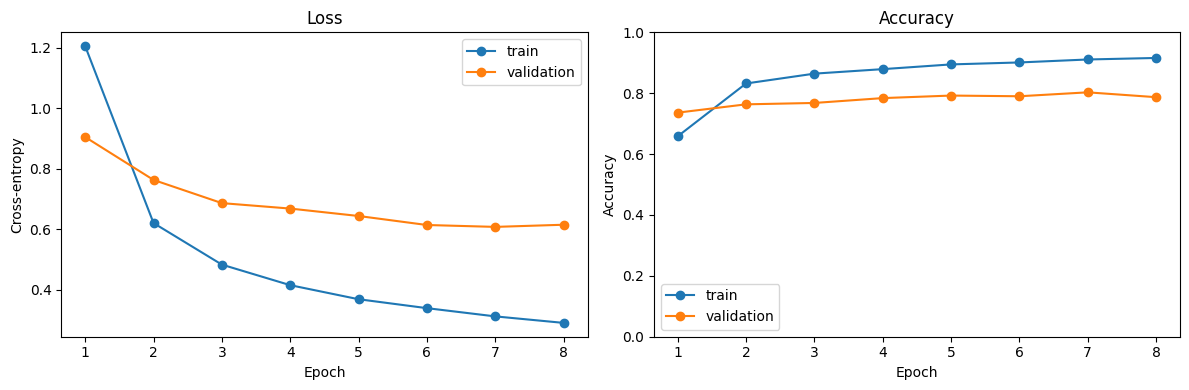

saved=evaluation_runs/transfer_training/learning_curves.png


In [9]:
epochs = [row["epoch"] for row in history]
train_losses = [row["train_loss"] for row in history]
val_losses = [row["val_loss"] for row in history]
train_accuracies = [row["train_accuracy"] for row in history]
val_accuracies = [row["val_accuracy"] for row in history]

figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, train_losses, marker="o", label="train")
axes[0].plot(epochs, val_losses, marker="o", label="validation")
axes[0].set(title="Loss", xlabel="Epoch", ylabel="Cross-entropy")
axes[0].legend()

axes[1].plot(epochs, train_accuracies, marker="o", label="train")
axes[1].plot(epochs, val_accuracies, marker="o", label="validation")
axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy", ylim=(0, 1))
axes[1].legend()

figure.tight_layout()
curve_path = RUN_DIR / "learning_curves.png"
figure.savefig(curve_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved={curve_path}")

## Next step

Evaluate `transfer_model.pt` on the untouched test split using the same accuracy and confusion-matrix procedure as the baseline. Do not adjust training choices based on test performance.

In [10]:
from google.colab import files

files.download("transfer_model.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>